# Market Making Backtest - Avellaneda-Stoikov

Implémentation du modèle classique d'optimisation de spreads en market making.

## Formule
**spread = (2/γ) × log(1 + γ/λ) + γ × inventory**

- γ (gamma): aversion au risque d'inventaire
- λ (lambda): intensité des ordres
- inventory: position courante

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class MarketMaker:
    def __init__(self, S0=100, sigma=0.2, lambda_=5, gamma=0.1, steps=500):
        self.S0 = S0
        self.sigma = sigma
        self.lambda_ = lambda_
        self.gamma = gamma
        self.steps = steps

    def optimal_spread(self, inventory):
        """Avellaneda-Stoikov spread formula"""
        base = (2 / self.gamma) * np.log(1 + self.gamma / self.lambda_)
        return base + self.gamma * inventory

    def simulate(self):
        prices = [self.S0]
        spreads = []
        inventories = [0]
        pnl_list = [0]

        inventory = 0
        cash = 0

        for t in range(self.steps):
            S = prices[-1]
            dS = self.sigma * np.random.randn() * 0.01
            S = S + dS
            prices.append(S)

            spread = self.optimal_spread(inventory)
            spreads.append(spread)

            bid = S - spread/2
            ask = S + spread/2

            if np.random.rand() < self.lambda_ * 0.01:
                inventory -= 1
                cash += ask

            if np.random.rand() < self.lambda_ * 0.01:
                inventory += 1
                cash -= bid

            inventories.append(inventory)
            unrealized = inventory * S
            pnl_list.append(cash + unrealized)

        return {
            'prices': prices,
            'spreads': spreads,
            'inventories': inventories,
            'pnl': pnl_list
        }

# RUN
np.random.seed(42)
mm = MarketMaker()
results = mm.simulate()

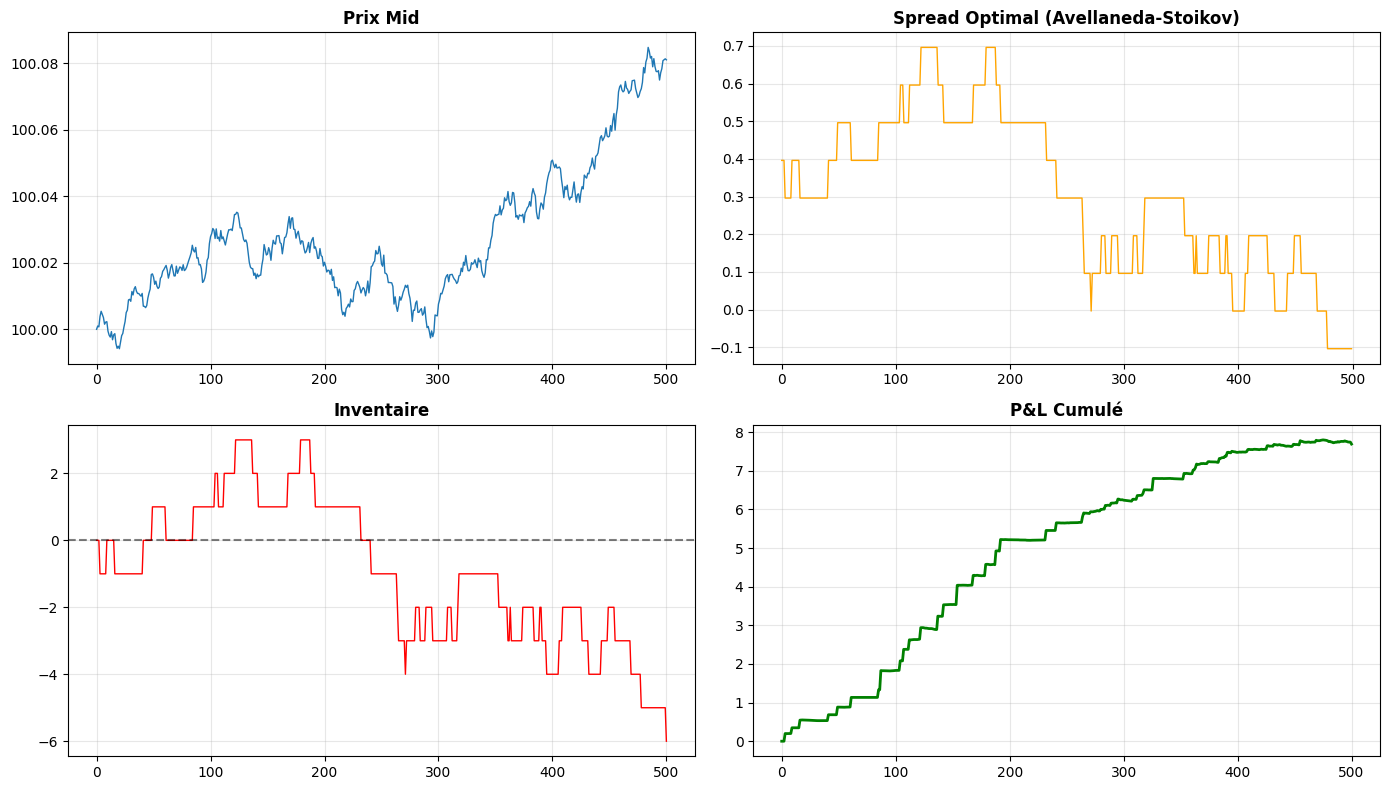

✅ Final P&L: 7.69
📊 Avg Spread: 0.3025
📈 Max Inventory: 3


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(results['prices'], linewidth=1)
axes[0, 0].set_title('Prix Mid', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results['spreads'], color='orange', linewidth=1)
axes[0, 1].set_title('Spread Optimal (Avellaneda-Stoikov)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results['inventories'], color='red', linewidth=1)
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Inventaire', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(results['pnl'], color='green', linewidth=2)
axes[1, 1].set_title('P&L Cumulé', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Final P&L: {results['pnl'][-1]:.2f}")
print(f"📊 Avg Spread: {np.mean(results['spreads']):.4f}")
print(f"📈 Max Inventory: {max(results['inventories'])}")

## Résultats

Le modèle montre comment les spreads s'ajustent automatiquement selon l'inventaire pour gérer le risque. Plus gamma est élevé, plus on élargit les spreads pour éviter de prendre trop de positions.